      Fecha        Ciudad  Temperatura Maxima  Temperatura Minima  \
0  1/1/2023  Buenos Aires                  27                  18   
1  1/1/2023       Cordoba                  35                  18   
2  1/1/2023       Rosario                  23                  21   
3  1/1/2023       Mendoza                  35                  21   
4  1/1/2023       Tucuman                  36                  18   

   Precipitacion  Velocidad del Viento  Humedad Relativa  
0            0.0                  22.7              68.8  
1            0.0                  33.8              61.7  
2            0.0                  10.6              80.0  
3            0.0                  23.8              76.8  
4           17.2                  25.7              54.9  
       Fecha        Ciudad  Temperatura Maxima  Temperatura Minima  \
0 2023-01-01  Buenos Aires                  27                  18   
1 2023-01-01       Cordoba                  35                  18   
2 2023-01-01       Ro

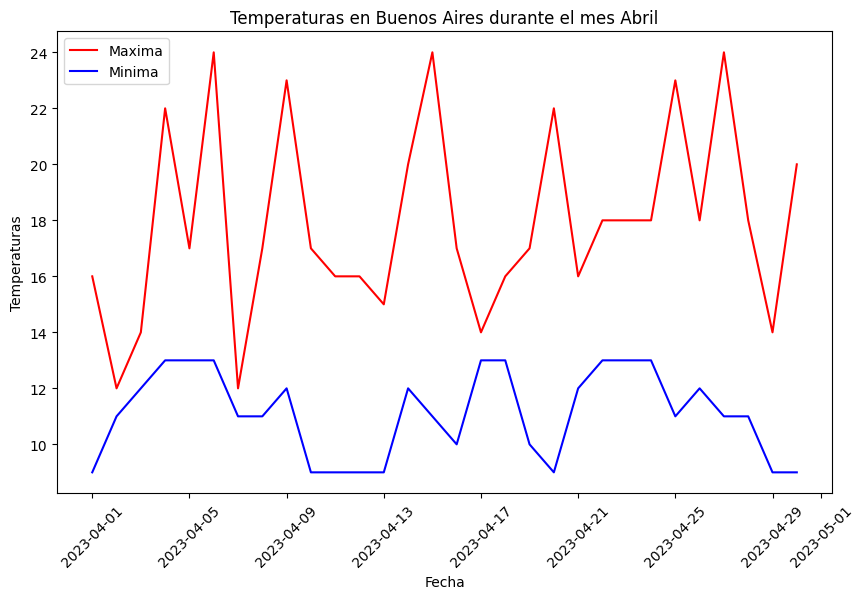

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

ruta = r"C:\Users\javie\OneDrive\Desktop\Excel_DB\Datos+Meteorológicos_Arg_2023.csv"
df = pd.read_csv(ruta)

print(df.head())

df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')
print(df.head())


lista_ciudades = []

for c in df['Ciudad']:
    if c not in lista_ciudades:
        lista_ciudades.append(c)
        print(lista_ciudades)

dict_meses = { 1: 'Enero',
                2: 'Febrero',
                3: 'Marzo',
                4: 'Abril',
                5: 'Mayo',
                6: 'Junio',
                7: 'Julio',
                8: 'Agosto',
                9: 'Septiembre',
                10: 'Octubre',
                11: 'Noviembre',
                12: 'Diciembre'}
def consultar_temps():
    while True:
        # Solicitar la ciudad
        print("\nCiudades disponibles: ", lista_ciudades)
        ciudad_elejida = input("Elija la ciudad de la lista: ").title()

        # Solicitar el mes
        mes_elegido = int(input("Elija un mes (por ej. Enero = 1): "))

        # Solicitar los inputs
        if ciudad_elejida not in lista_ciudades or mes_elegido not in range(1, 13):
            print("Ciudad o Mes no Válidos. Inténtelo Nuevamente.")
            continue

        # Crear el dataframe filtrando
        datos_ciudad_mes = df[(df['Ciudad'] == ciudad_elejida) & (df['Fecha'].dt.month == mes_elegido)]

        # Gráficamos las temperaturas del dataframe
        plt.figure(figsize=(10, 6))
        plt.plot(datos_ciudad_mes['Fecha'], datos_ciudad_mes['Temperatura Maxima'], label="Maxima", color="red")
        plt.plot(datos_ciudad_mes['Fecha'], datos_ciudad_mes['Temperatura Minima'], label="Minima", color="blue")
        plt.title(f"Temperaturas en {ciudad_elejida} durante el mes {dict_meses[mes_elegido]}")
        plt.xlabel("Fecha")
        plt.ylabel("Temperaturas")
        plt.legend()
        plt.xticks(rotation=45)
        plt.show()

        #Preguntar al usuario si quiere continuar
        otra_consulta = input("¿Desea continuar consultando? (s/n): ")
        if otra_consulta.lower() != 's':
            break

consultar_temps()